# 01 — Explore Raw Data

Load and inspect the raw micro-CT TIFF stack. Understand the data before any processing.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from research_ct.io.volume_loader import Load_Slice_Stack
from research_ct.io.metadata_parser import Load_Metadata

# Adjust this path to your data
DATA_DIR = Path(r"C:\Users\gabri\Documento\Mitacs\research_ct\data\raw")

# Load volume
Volume = Load_Slice_Stack(DATA_DIR, Pattern="*.tif*", Stop=40)
print(f"Volume shape: {Volume.shape}")
print(f"Dtype: {Volume.dtype}")
print(f"Range: [{Volume.min():.1f}, {Volume.max():.1f}]")

[Load_Slice_Stack] 40 slices from C:\Users\gabri\Documento\Mitacs\research_ct\data\raw (range 0:40:1 of 201 total)
[Load_Slice_Stack] Volume: (40, 1828, 2165), range [0.0, 60735.0]
Volume shape: (40, 1828, 2165)
Dtype: float64
Range: [0.0, 60735.0]


## Inspect Metadata

Since we only have TIFF files, metadata is inferred from array properties.

In [2]:
Metadata = Load_Metadata(Volume, Voxel_Size_Um=40.0, Num_Pages=200)
print(f"Inferred shape: {Metadata.Volume_Shape}")
print(f"Bit depth: {Metadata.Bit_Depth}")
print(f"Intensity range: {Metadata.Intensity_Range}")
print(f"Voxel size (um): {Metadata.Voxel_Size_Um}")

[Load_Metadata] Inferred: shape=(40, 1828, 2165), bit_depth=64, range=(0.0, 60735.0)
Inferred shape: (40, 1828, 2165)
Bit depth: 64
Intensity range: (0.0, 60735.0)
Voxel size (um): (40.0, 40.0, 40.0)


## Visualize Slices

Look at representative slices across the Z axis.

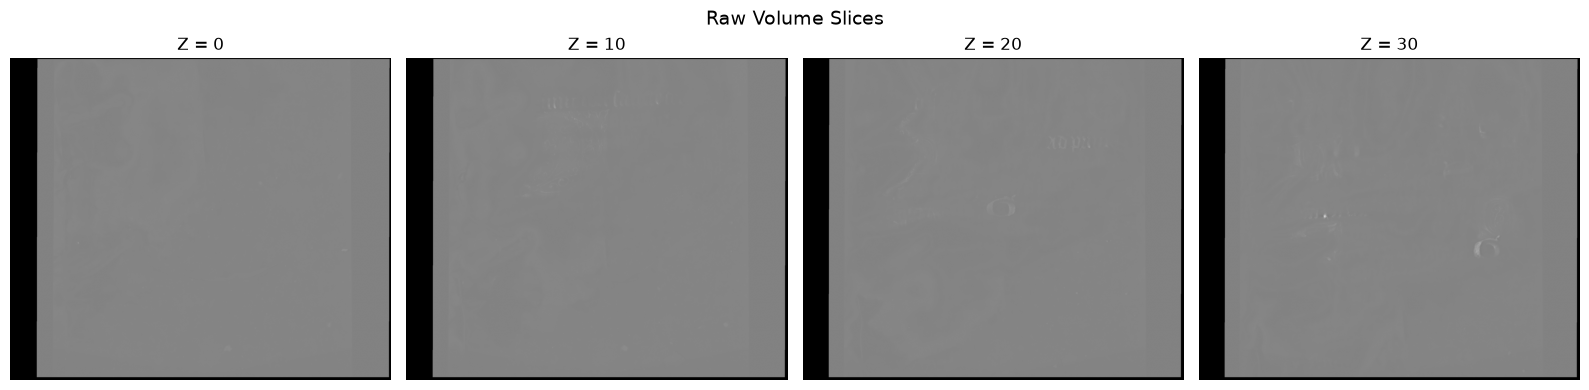

In [3]:
D, H, W = Volume.shape
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

slice_indices = [0, D//4, D//2, 3*D//4]
for ax, z in zip(axes, slice_indices):
    ax.imshow(Volume[z], cmap='gray', vmin=Volume.min(), vmax=Volume.max())
    ax.set_title(f'Z = {z}')
    ax.axis('off')

plt.suptitle('Raw Volume Slices', fontsize=14)
plt.tight_layout()
plt.show()

## Global Intensity Histogram

Check how many modes are visible. This informs GMM component count.

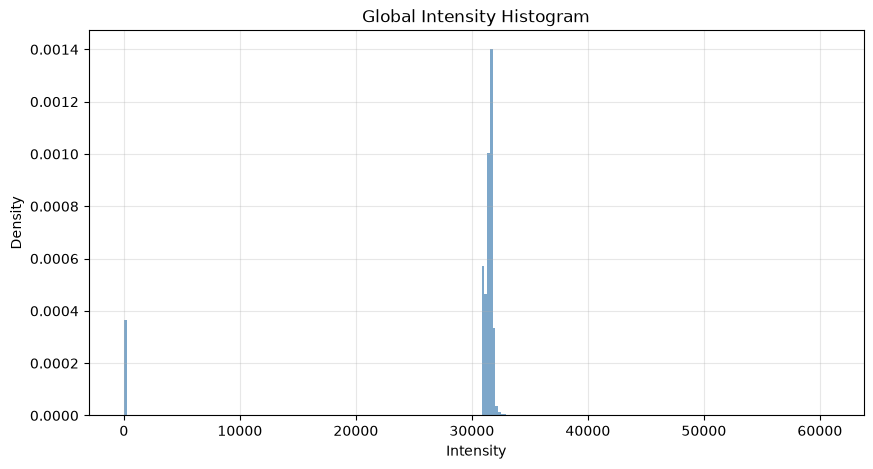

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(Volume.ravel(), bins=256, density=True, alpha=0.7, color='steelblue')
ax.set_xlabel('Intensity')
ax.set_ylabel('Density')
ax.set_title('Global Intensity Histogram')
ax.grid(True, alpha=0.3)
plt.show()

## Local Histograms (Slice-wise)

Check if distributions vary across the volume. Non-stationarity may need local adaptation.

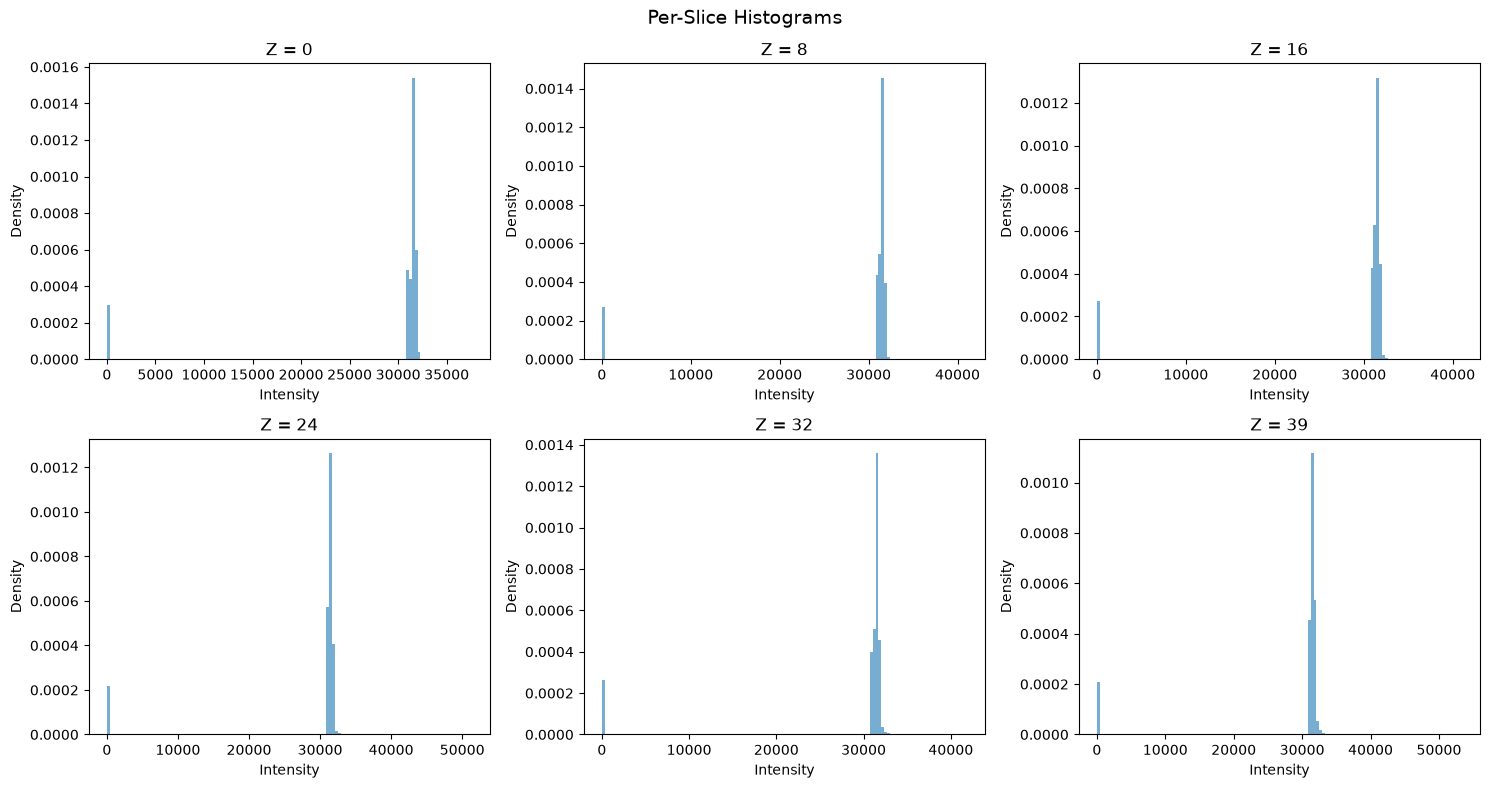

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for i, z in enumerate([0, D//5, 2*D//5, 3*D//5, 4*D//5, D-1]):
    axes[i].hist(Volume[z].ravel(), bins=128, density=True, alpha=0.6)
    axes[i].set_title(f'Z = {z}')
    axes[i].set_xlabel('Intensity')
    axes[i].set_ylabel('Density')

plt.suptitle('Per-Slice Histograms', fontsize=14)
plt.tight_layout()
plt.show()

## Summary

Before proceeding, note:
- Number of visible histogram modes (air, paper, ink, cover?)
- Presence of outliers or saturation
- Spatial variation in intensity distributions
- Approximate page locations (if visible in slices)